# Notebook 3: Visualization and Analysis
## Healthcare Symptom Pattern Discovery — Task 3
**Objective:** Produce comprehensive visualisations of the discovered clusters:
PCA scatter plots, t-SNE projection, cluster-symptom heatmaps, silhouette plots,
and cluster composition charts.

**Input :** `task2_clustered.csv`  
**Output:** `task3_viz_data.csv` → fed into Notebook 4


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.manifold import TSNE

np.random.seed(42)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# ── Colour helper: supports ANY number of clusters, ANY label origin ──────────
# tab20 + tab20b + tab20c = 60 perceptually distinct colours.
# get_color(label, all_labels) maps a label to a stable RGBA colour regardless
# of whether labels are 0-indexed (GMM) or 1-indexed (HC).

_CMAPS = [cm.get_cmap('tab20'), cm.get_cmap('tab20b'), cm.get_cmap('tab20c')]

def get_color(label, all_labels):
    """Return a stable RGBA colour for label given the full label universe."""
    idx = sorted(set(all_labels)).index(label)   # rank among unique labels
    return _CMAPS[(idx // 20) % 3]((idx % 20) / 20)

print("Setup complete. Colour helper supports up to 60 distinct clusters.")


Setup complete. Colour helper supports up to 60 distinct clusters.


In [2]:
# ── Load data from Notebook 2 ────────────────────────────────────────────────
df = pd.read_csv('..//Result_NB2/task2_clustered.csv', index_col=0)
print(f"Loaded shape: {df.shape}")

meta_cols = ['Disease','hc_cluster','gmm_cluster','gmm_confidence','pca_1','pca_2','pca_3']
symptom_cols = [c for c in df.columns if c not in meta_cols]

X           = df[symptom_cols].astype(float)
hc_labels   = df['hc_cluster'].values
gmm_labels  = df['gmm_cluster'].values
disease_lbl = df['Disease']
pca1, pca2  = df['pca_1'].values, df['pca_2'].values
pca3        = df['pca_3'].values

n_clusters = len(np.unique(hc_labels))
print(f"Number of HC clusters: {n_clusters}")
print(f"Cluster sizes (HC):")
print(pd.Series(hc_labels).value_counts().sort_index().to_string())


Loaded shape: (4920, 165)
Number of HC clusters: 41
Cluster sizes (HC):
1     120
2     120
3     120
4     120
5     120
6     120
7     120
8     120
9     120
10    120
11    120
12    120
13    120
14    120
15    120
16    120
17    120
18    120
19    120
20    120
21    120
22    120
23    120
24    120
25    120
26    120
27    120
28    120
29    120
30    120
31    120
32    114
33    114
34    120
35    132
36    120
37    120
38    120
39    120
40    120
41    120


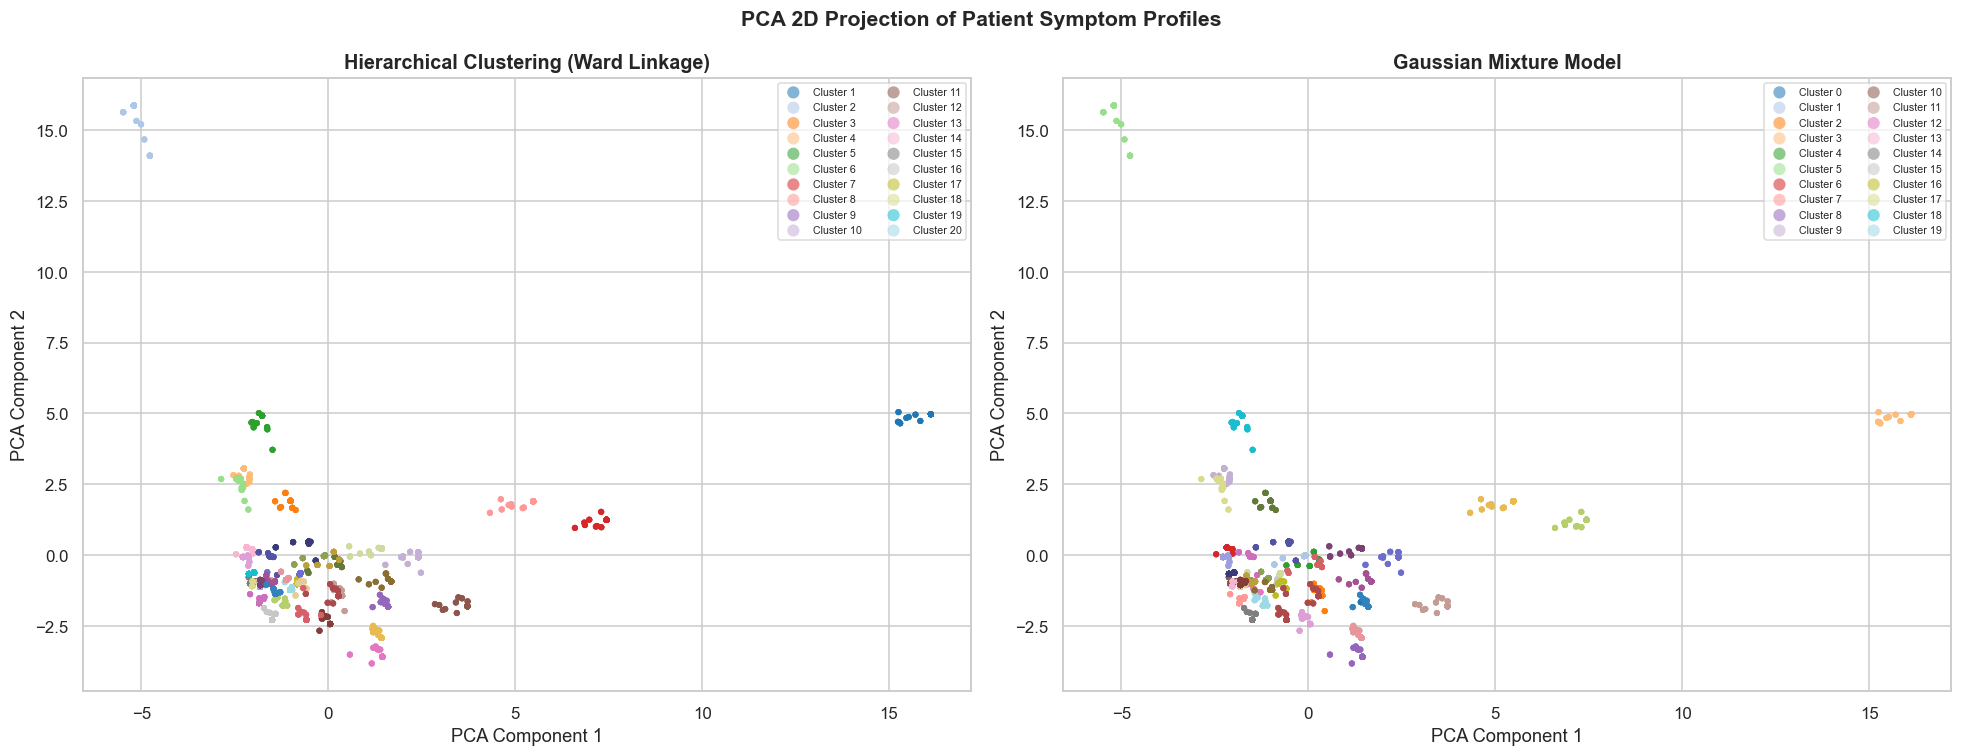

Saved -> ..//Result_NB3/task3_pca_scatter.png


In [3]:
# Figure 1: PCA 2D Scatter — HC vs GMM
# Shows how well each algorithm separates patient records in PCA space.
# Overlapping regions indicate patients with ambiguous/mixed symptom profiles.
# get_color() replaces PALETTE[k-1] — works for any number of clusters
# and any label origin (0-indexed GMM or 1-indexed HC).

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, labels, title in zip(
    axes,
    [hc_labels, gmm_labels],
    ['Hierarchical Clustering (Ward Linkage)', 'Gaussian Mixture Model']
):
    unique_labels = sorted(np.unique(labels))
    for k in unique_labels:
        mask = labels == k
        ax.scatter(pca1[mask], pca2[mask],
                   color=get_color(k, labels),   # safe for any k, any origin
                   label=f'Cluster {k}',
                   alpha=0.55, s=16, edgecolors='none')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    # Legend: show max 20 entries to avoid clutter
    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles[:20], lbls[:20], markerscale=2, fontsize=7,
              loc='best', ncol=2, framealpha=0.7)

plt.suptitle('PCA 2D Projection of Patient Symptom Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('..//Result_NB3/task3_pca_scatter.png', bbox_inches='tight')
plt.show()
print("Saved -> ..//Result_NB3/task3_pca_scatter.png")


Using 30 PCA dimensions for t-SNE: ['pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5']...
t-SNE complete. Output shape: (4920, 2)


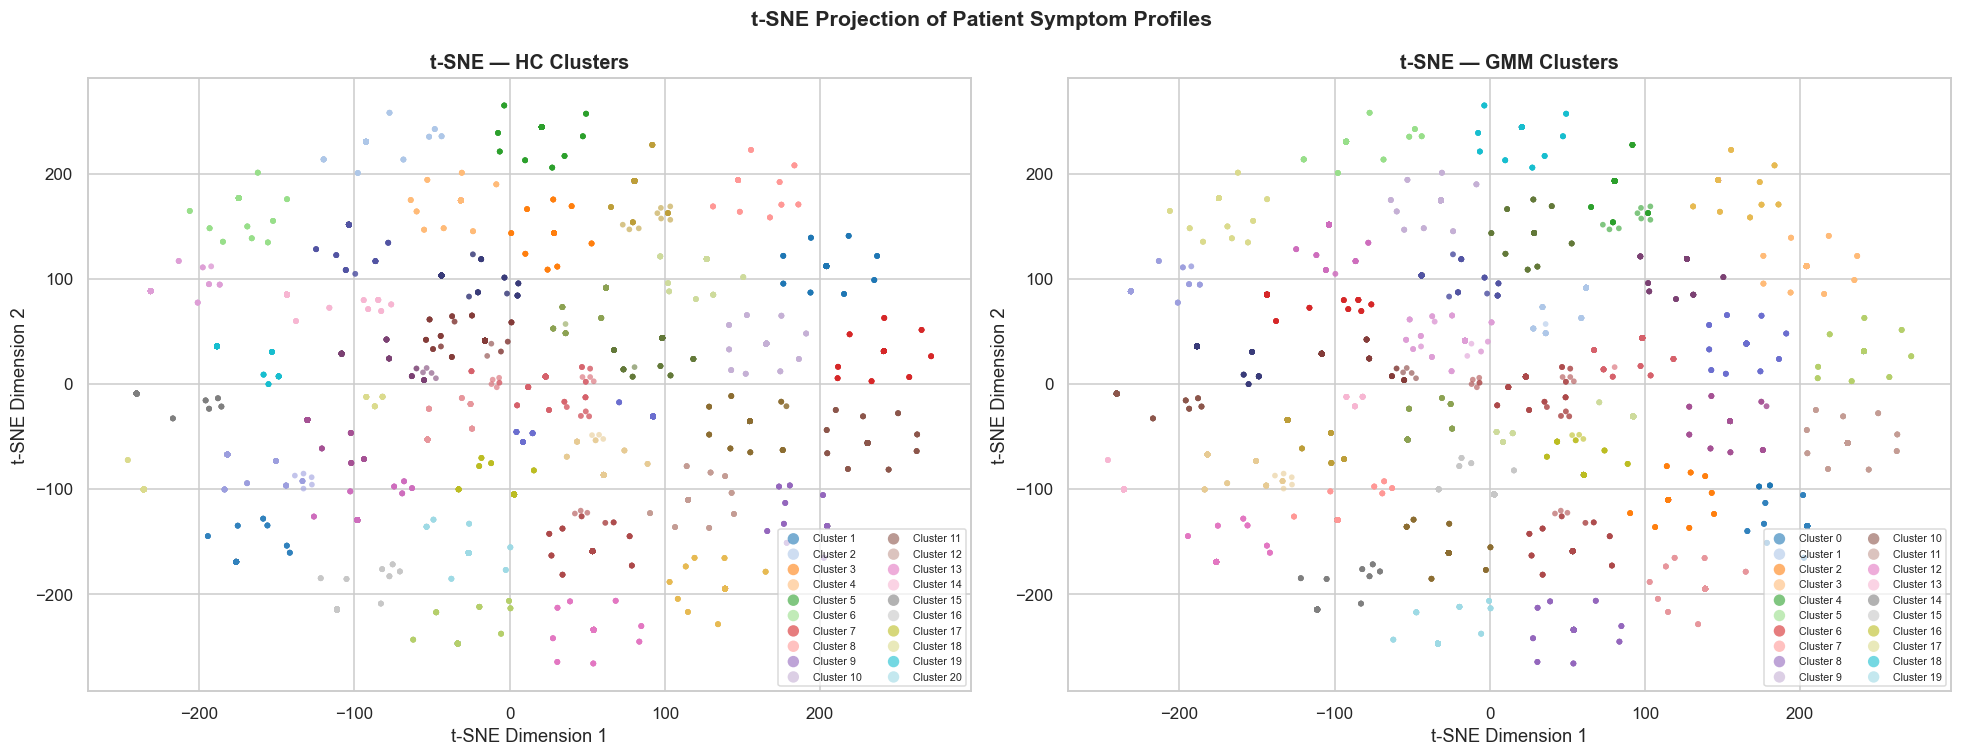

Saved -> ..//Result_NB3/task3_tsne_scatter.png


In [4]:
# Figure 2: t-SNE Projection
# Run t-SNE on ALL stored PCA coordinates (up to 30), not just [pca1,pca2,pca3].
# Using only 3 dims discards 70%+ of the structure recovered by the NB2 fix.

# Gather all pca_* columns (NB2 now stores pca_1..pca_30 or similar)
pca_cols = sorted([c for c in df.columns if c.startswith('pca_')],
                  key=lambda x: int(x.split('_')[1]))
print(f"Using {len(pca_cols)} PCA dimensions for t-SNE: {pca_cols[:5]}...")

pca_data = df[pca_cols].values   # shape (4920, n_pca_cols)

tsne = TSNE(n_components=2, perplexity=40, learning_rate=200, random_state=42)
tsne_xy = tsne.fit_transform(pca_data)
print(f"t-SNE complete. Output shape: {tsne_xy.shape}")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, labels, title in zip(
    axes,
    [hc_labels, gmm_labels],
    ['HC Clusters', 'GMM Clusters']
):
    for k in sorted(np.unique(labels)):
        mask = labels == k
        ax.scatter(tsne_xy[mask, 0], tsne_xy[mask, 1],
                   color=get_color(k, labels),
                   label=f'Cluster {k}',
                   alpha=0.6, s=14, edgecolors='none')
    ax.set_title(f't-SNE — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')
    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles[:20], lbls[:20], markerscale=2, fontsize=7, ncol=2, framealpha=0.7)

plt.suptitle('t-SNE Projection of Patient Symptom Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('..//Result_NB3/task3_tsne_scatter.png', bbox_inches='tight')
plt.show()
print("Saved -> ..//Result_NB3/task3_tsne_scatter.png")


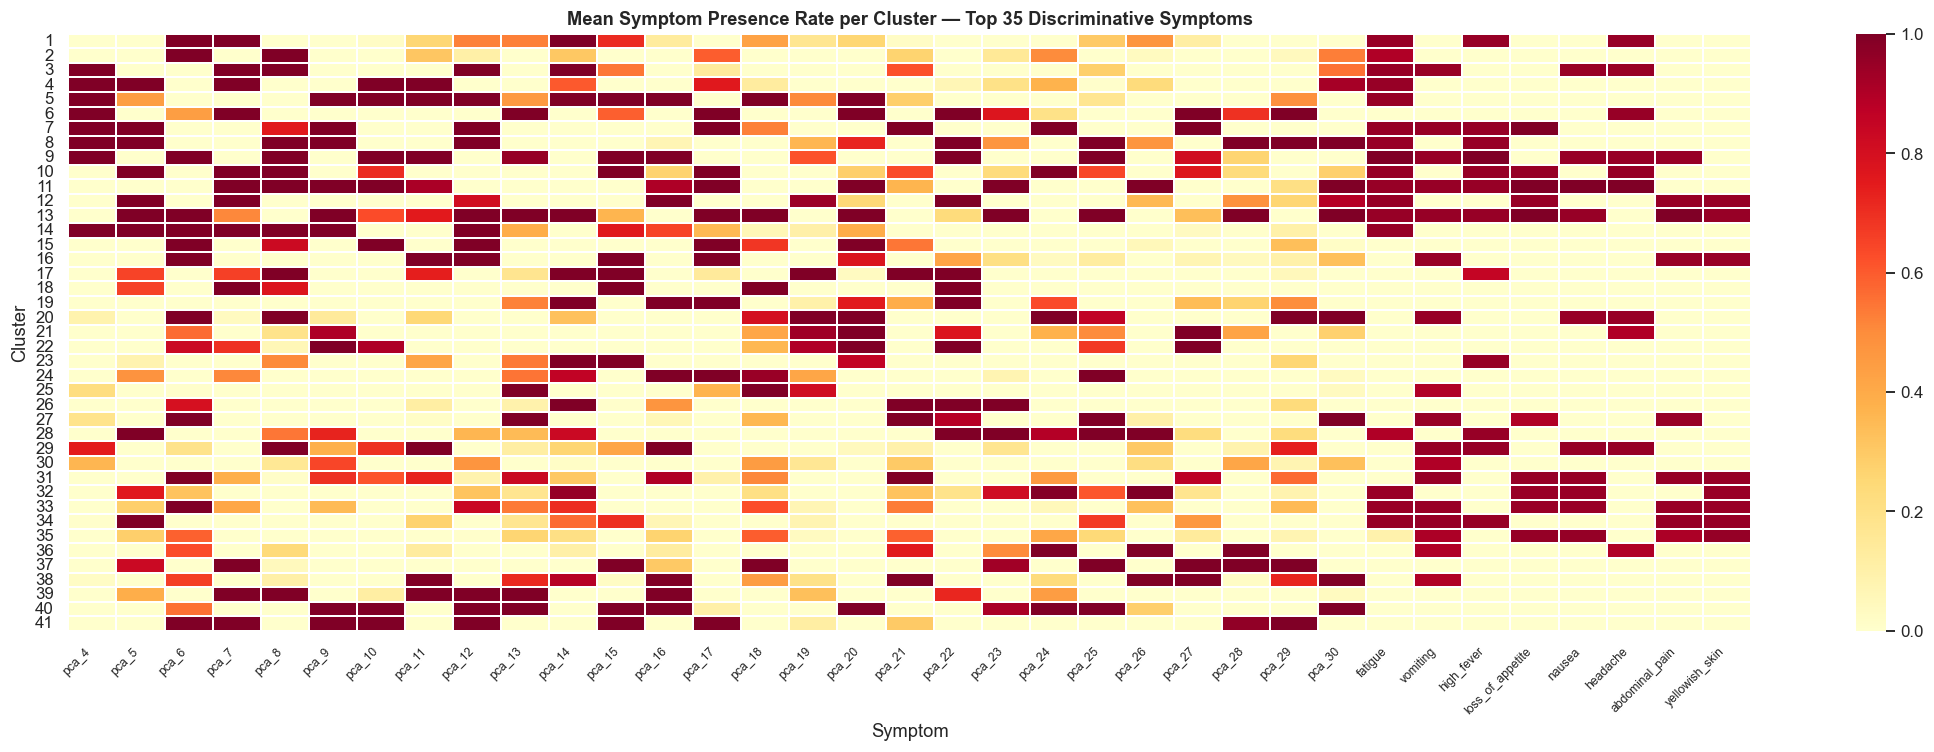

Saved → ..//Result_NB3/task3_cluster_symptom_heatmap.png


In [5]:
# ── Figure 3: Cluster-Symptom Heatmap ───────────────────────────────────────
# Computes the mean symptom presence rate per cluster.
# Shows which symptoms define each cluster (hot = prevalent in that cluster).
# We display the top 35 symptoms by across-cluster variance (most discriminative).

cluster_df = pd.DataFrame(X.values, columns=symptom_cols)
cluster_df['cluster'] = hc_labels
cluster_mean = cluster_df.groupby('cluster').mean()

top_sym = cluster_mean.var(axis=0).nlargest(35).index.tolist()

fig, ax = plt.subplots(figsize=(20, 7))
sns.heatmap(cluster_mean[top_sym], cmap='YlOrRd', linewidths=0.3,
            vmin=0, vmax=1, annot=False, ax=ax,
            xticklabels=True, yticklabels=True)
ax.set_title('Mean Symptom Presence Rate per Cluster — Top 35 Discriminative Symptoms',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Symptom')
ax.set_ylabel('Cluster')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('..//Result_NB3/task3_cluster_symptom_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved → ..//Result_NB3/task3_cluster_symptom_heatmap.png")


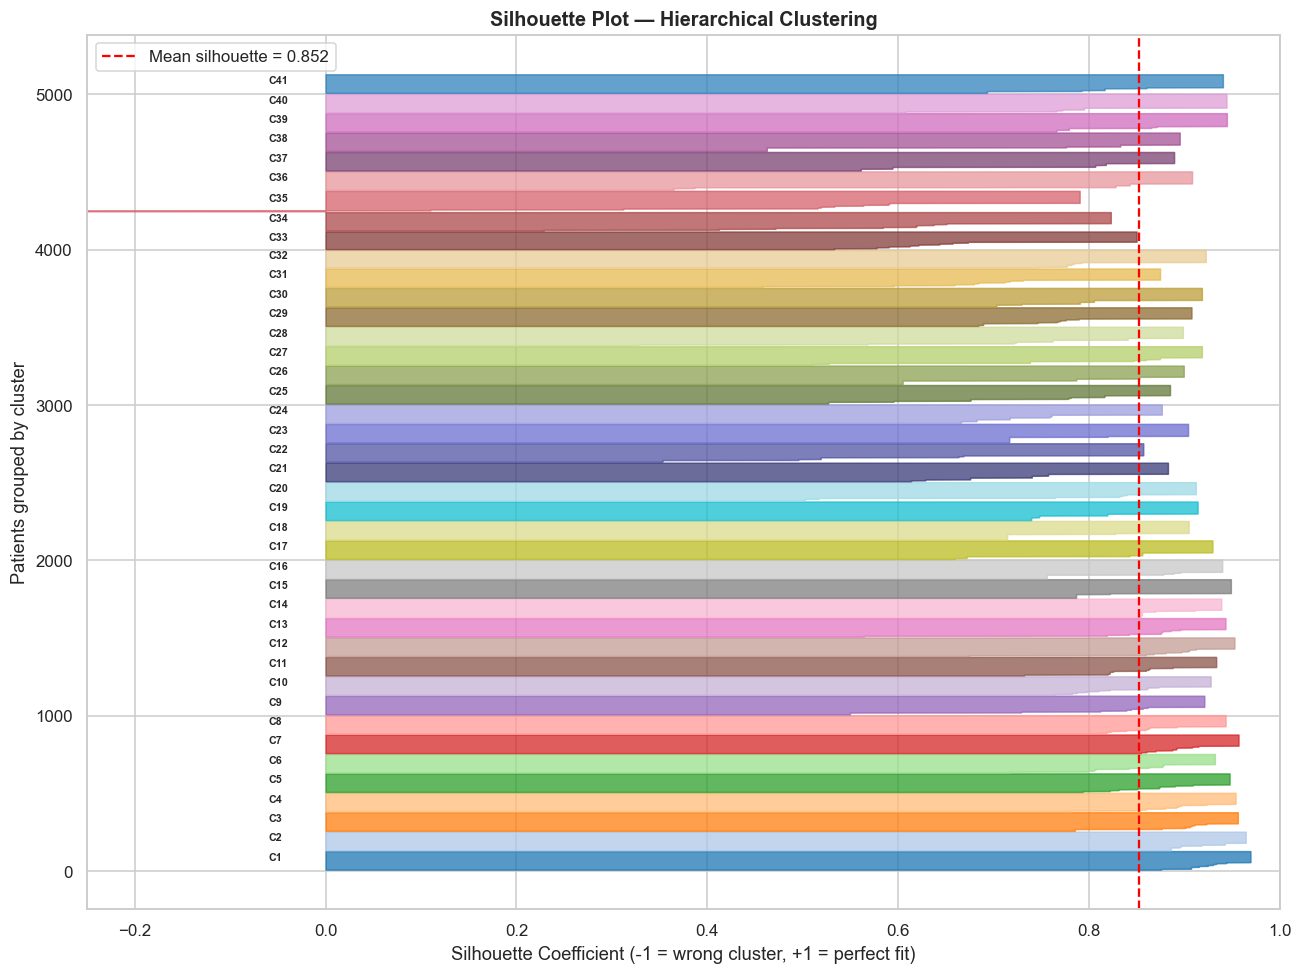

Overall silhouette score: 0.8521
Saved -> ..//Result_NB3/task3_silhouette_plot.png


In [6]:
# Figure 4: Silhouette Plot
# compute silhouette on all PCA dims (pca_data), not the old 3-D coords.
# This gives accurate per-sample coefficients consistent with the clustering.

sample_sils = silhouette_samples(pca_data, hc_labels)
overall_sil = silhouette_score(pca_data, hc_labels)

fig, ax = plt.subplots(figsize=(12, max(8, n_clusters * 0.22)))
y_lower = 10

for k in sorted(np.unique(hc_labels)):
    sils_k  = np.sort(sample_sils[hc_labels == k])
    y_upper = y_lower + len(sils_k)
    color   = get_color(k, hc_labels)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sils_k,
                     facecolor=color, edgecolor=color, alpha=0.75)
    ax.text(-0.06, y_lower + 0.5*len(sils_k), f'C{k}', fontsize=7, fontweight='bold')
    y_lower = y_upper + 5

ax.axvline(x=overall_sil, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean silhouette = {overall_sil:.3f}')
ax.set_title('Silhouette Plot — Hierarchical Clustering', fontsize=13, fontweight='bold')
ax.set_xlabel('Silhouette Coefficient (-1 = wrong cluster, +1 = perfect fit)')
ax.set_ylabel('Patients grouped by cluster')
ax.set_xlim([-0.25, 1.0])
ax.legend()
plt.tight_layout()
plt.savefig('..//Result_NB3/task3_silhouette_plot.png', bbox_inches='tight')
plt.show()
print(f"Overall silhouette score: {overall_sil:.4f}")
print("Saved -> ..//Result_NB3/task3_silhouette_plot.png")


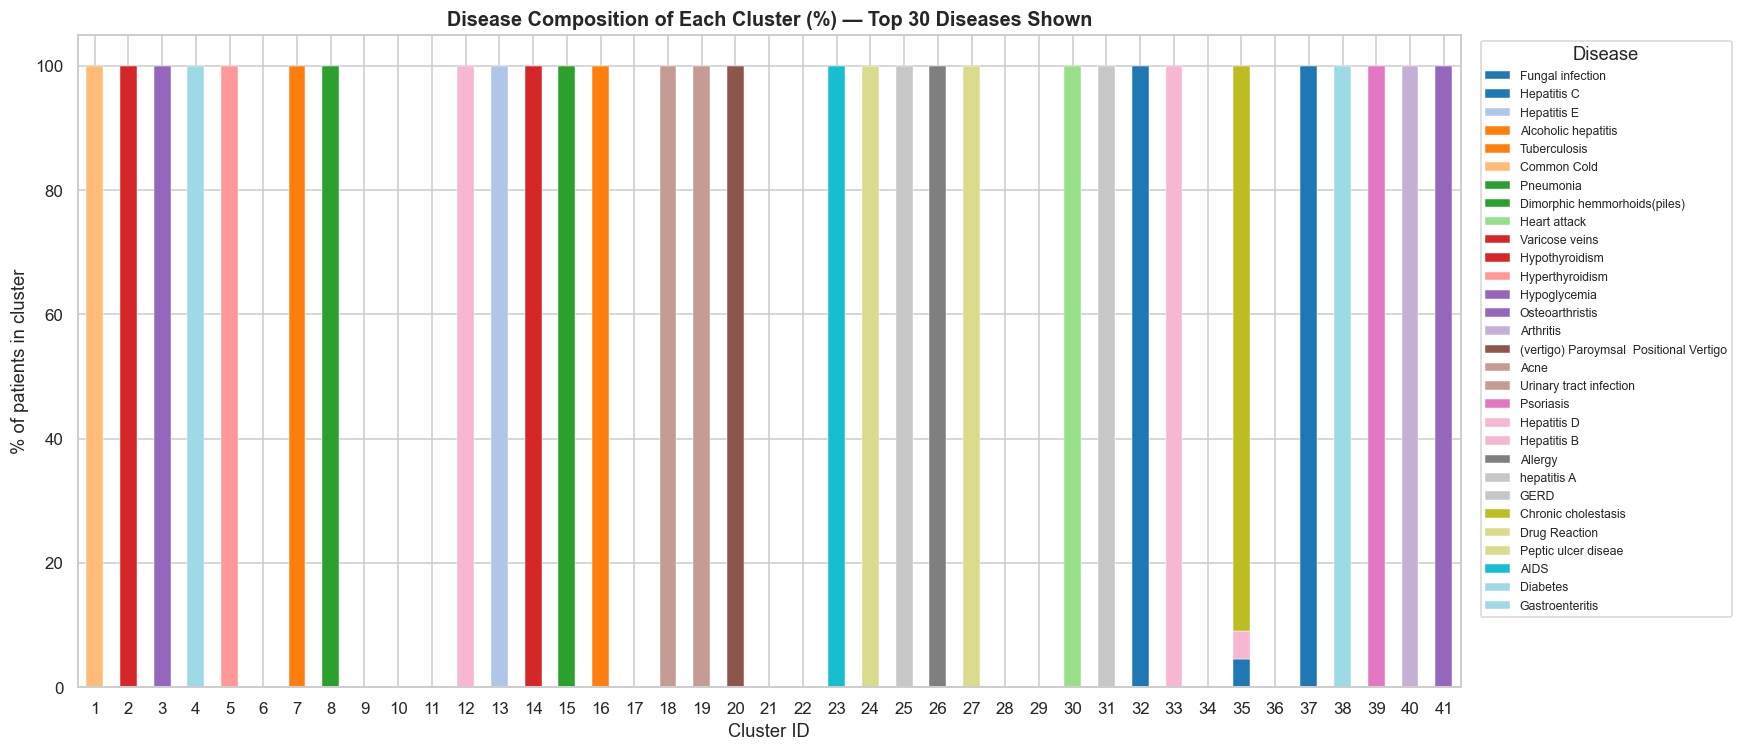

Saved → ..//Result_NB3/task3_cluster_composition.png


In [7]:
# ── Figure 5: Disease Composition per Cluster (Stacked Bar) ─────────────────
# Shows how known diseases distribute across clusters.
# Since diseases were hidden during clustering, this is an indirect quality check.
# A cluster dominated by one disease = high medical coherence.

comp = pd.crosstab(hc_labels, disease_lbl, normalize='index') * 100
top_diseases = disease_lbl.value_counts().head(30).index
comp_top = comp[top_diseases]

fig, ax = plt.subplots(figsize=(16, 7))
comp_top.plot(kind='bar', stacked=True, ax=ax,
              colormap='tab20', edgecolor='white', linewidth=0.3)
ax.set_title('Disease Composition of Each Cluster (%) — Top 30 Diseases Shown',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('% of patients in cluster')
ax.legend(title='Disease', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('..//Result_NB3/task3_cluster_composition.png', bbox_inches='tight')
plt.show()
print("Saved → ..//Result_NB3/task3_cluster_composition.png")


In [8]:
# ── Save enriched data with t-SNE coordinates ────────────────────────────────
df['tsne_1'] = tsne_xy[:, 0]
df['tsne_2'] = tsne_xy[:, 1]

df.to_csv('..//Result_NB3/task3_viz_data.csv', index=False)
print(f"✅ Saved: ..//Result_NB3/task3_viz_data.csv  |  shape: {df.shape}")
print("\n→ Next step: Run Notebook 4 (Medical Interpretation)")


✅ Saved: ..//Result_NB3/task3_viz_data.csv  |  shape: (4920, 167)

→ Next step: Run Notebook 4 (Medical Interpretation)
